<a href="https://colab.research.google.com/github/2d-game-dev/Optimization_University_Lab/blob/main/OptimizationLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

def f(x):
    x1, x2 = x
    return 0.5 * (4*x1**2 - 2*x1*x2 + 5*x2**2) - 9*x1 + 7*x2

def grad_f(x):
    x1, x2 = x
    return np.array([
        0.5 * (8*x1 - 2*x2) - 9,
        0.5 * (-2*x1 + 10*x2) + 7
    ])

A = np.array([
    [4, -1],
    [-1, 5]
])

def exact_step_size(x, g):#counts the best step size
    return np.dot(g, g) / np.dot(g, np.dot(A, g))

x = np.array([3.0, -3.0])

eps = 1e-3
k = 0


print(f"{'k':<4} {'x1':<12} {'x2':<12} {'Step Size (α_k)':<16} {'Slope Magnitude (||∇f||)':<25}")
print("-" * 70)

while True:
    g = grad_f(x)
    slope_magnitude = np.linalg.norm(g)   # Հաշվում է վեկտորի ԵՐԿԱՐՈՒԹՅՈՒՆԸ

    if k == 0:
        print(f"{k:<4} {x[0]:<12.4f} {x[1]:<12.4f} {'---':<16} {slope_magnitude:<25.4f}")
    else:
        print(f"{k:<4} {x[0]:<12.4f} {x[1]:<12.4f} {alpha_k:<16.6f} {slope_magnitude:<25.4f}")


    if slope_magnitude < eps:
        break

    alpha_k = exact_step_size(x, g)
    x = x - alpha_k * g
    k += 1

print("\n")

print("FINAL RESULTS")
print("-" * 60)
print(f"Number of steps taken: {k}")
print(f"Minimum point x* = ({x[0]:.4f}, {x[1]:.4f})")
print(f"Minimum value f(x*) = {f(x):.4f}")
print(f"Stopping condition value (||∇f||) = {np.linalg.norm(grad_f(x)):.4f}")
print(f"Stopping tolerance (ε) = {eps}")
print(f"Status: {np.linalg.norm(grad_f(x)):.4f} < {eps} → STOPPED")


k    x1           x2           Step Size (α_k)  Slope Magnitude (||∇f||) 
----------------------------------------------------------------------
0    3.0000       -3.0000      ---              12.5300                  
1    1.9308       -1.0397      0.178207         0.2702                   
2    2.0008       -1.0015      0.295113         0.0097                   
3    1.9999       -1.0000      0.178207         0.0002                   


FINAL RESULTS
------------------------------------------------------------
Number of steps taken: 3
Minimum point x* = (1.9999, -1.0000)
Minimum value f(x*) = -12.5000
Stopping condition value (||∇f||) = 0.0002
Stopping tolerance (ε) = 0.001
Status: 0.0002 < 0.001 → STOPPED


In [ ]:
offers = [12, 20, 32]
probs = [0.3, 0.4, 0.3]
T = 7

v = {}
v[T + 1] = 0

print("BELLMAN EQUATION:")
print("v_t = Σ p(w) × max(w, v_{t+1})")
print("where v_{T+1} = 0")
print()

print(f"{'Period':<8} {'v_{t+1} (Future)':<18} {'Reservation Value':<18} {'v_t (Current)':<15}")
print("-" * 70)

for t in range(T, 0, -1):
    continuation = v[t + 1]
    reservation = continuation# Минимальное предложение, которое стоит принять

    expected_value = 0
    for w, p in zip(offers, probs):
        expected_value += p * max(w, continuation)

    v[t] = expected_value

    print(f"{t:<8} {continuation:<18.4f} {reservation:<18.4f} {v[t]:<15.4f}")

print("\n" + "-" * 70)
print(f"EXPECTED VALUE AT START (v₁) = {v[1]:.4f}")
print("-" * 70)

BELLMAN EQUATION:
v_t = Σ p(w) × max(w, v_{t+1})
where v_{T+1} = 0

Period   v_{t+1} (Future)   Reservation Value  v_t (Current)  
----------------------------------------------------------------------
7        0.0000             0.0000             21.2000        
6        21.2000            21.2000            24.4400        
5        24.4400            24.4400            26.7080        
4        26.7080            26.7080            28.2956        
3        28.2956            28.2956            29.4069        
2        29.4069            29.4069            30.1848        
1        30.1848            30.1848            30.7294        

----------------------------------------------------------------------
EXPECTED VALUE AT START (v₁) = 30.7294
----------------------------------------------------------------------


TASK 1: Single Chain Simulation (365 days)


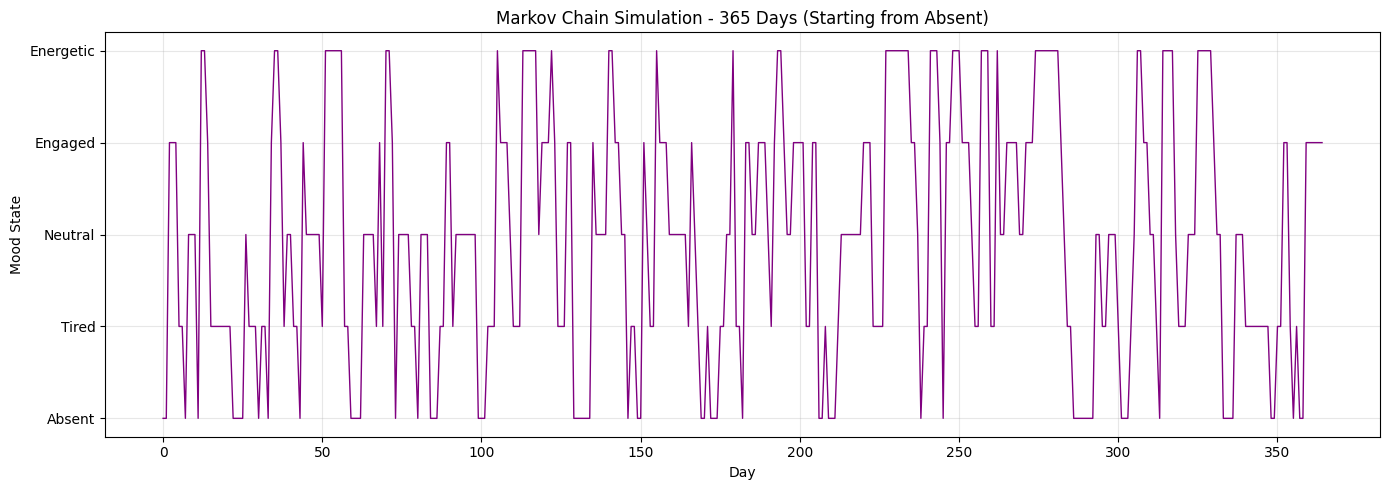


Empirical fractions (1 chain, 365 days):
  Absent    : 0.1781
  Tired     : 0.2301
  Neutral   : 0.2274
  Engaged   : 0.1945
  Energetic : 0.1699


TASK 2: 2000 Simulations, each 365 days

Empirical distribution across all 2000 simulations:
  Absent    : 0.172581
  Tired     : 0.223766
  Neutral   : 0.219022
  Engaged   : 0.208196
  Energetic : 0.176436


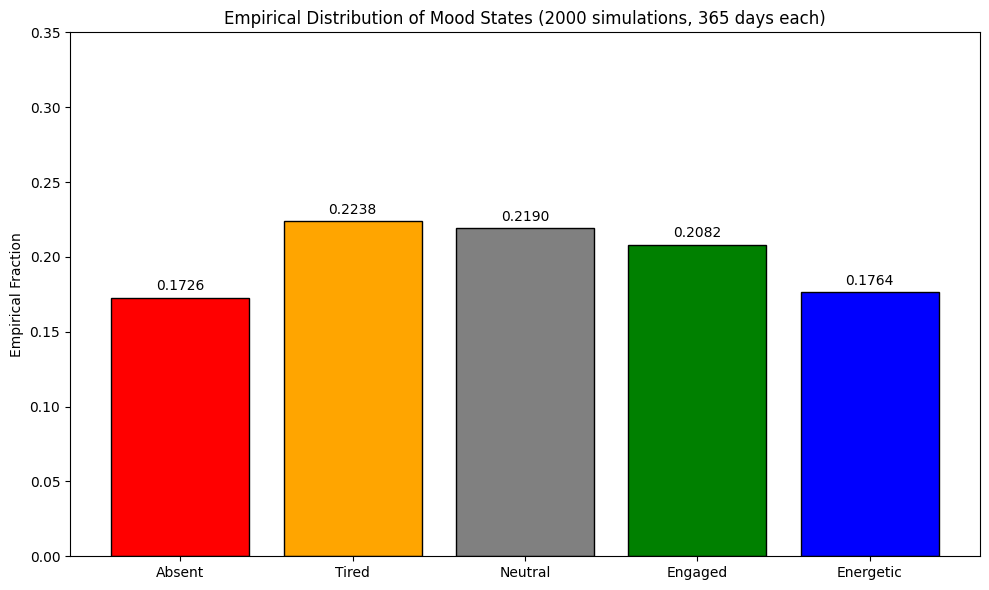



TASK 3: Stationary Distribution

Method 1 (Eigenvalue):
  Absent    : 0.16875671
  Tired     : 0.22307563
  Neutral   : 0.21943315
  Engaged   : 0.20998794
  Energetic : 0.17874656

Method 2 (Linear system):
  Absent    : 0.16875671
  Tired     : 0.22307563
  Neutral   : 0.21943315
  Engaged   : 0.20998794
  Energetic : 0.17874656

Max difference between methods: 1.94e-16


COMPARISON: Stationary vs Empirical Distribution

State        Stationary   Empirical    Difference  
--------------------------------------------------
Absent           0.168757     0.172581    -0.003824
Tired            0.223076     0.223766    -0.000690
Neutral          0.219433     0.219022     0.000411
Engaged          0.209988     0.208196     0.001792
Energetic        0.178747     0.176436     0.002311


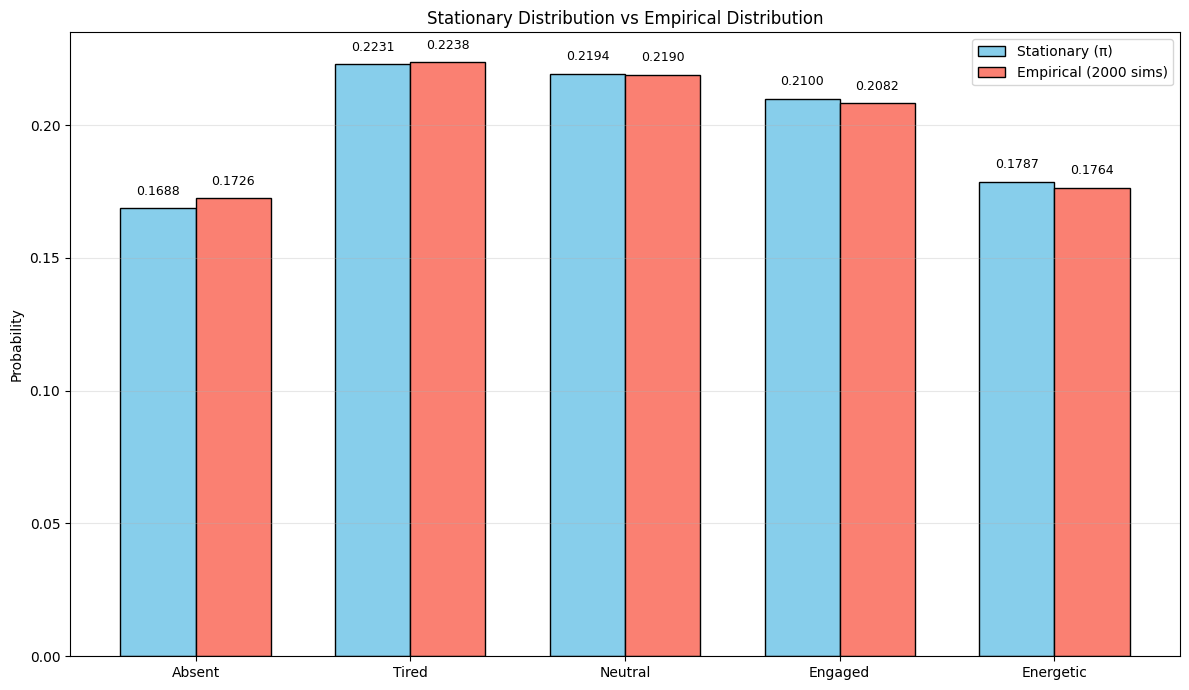



EXTRA: First 5 Simulations (each 365 days)


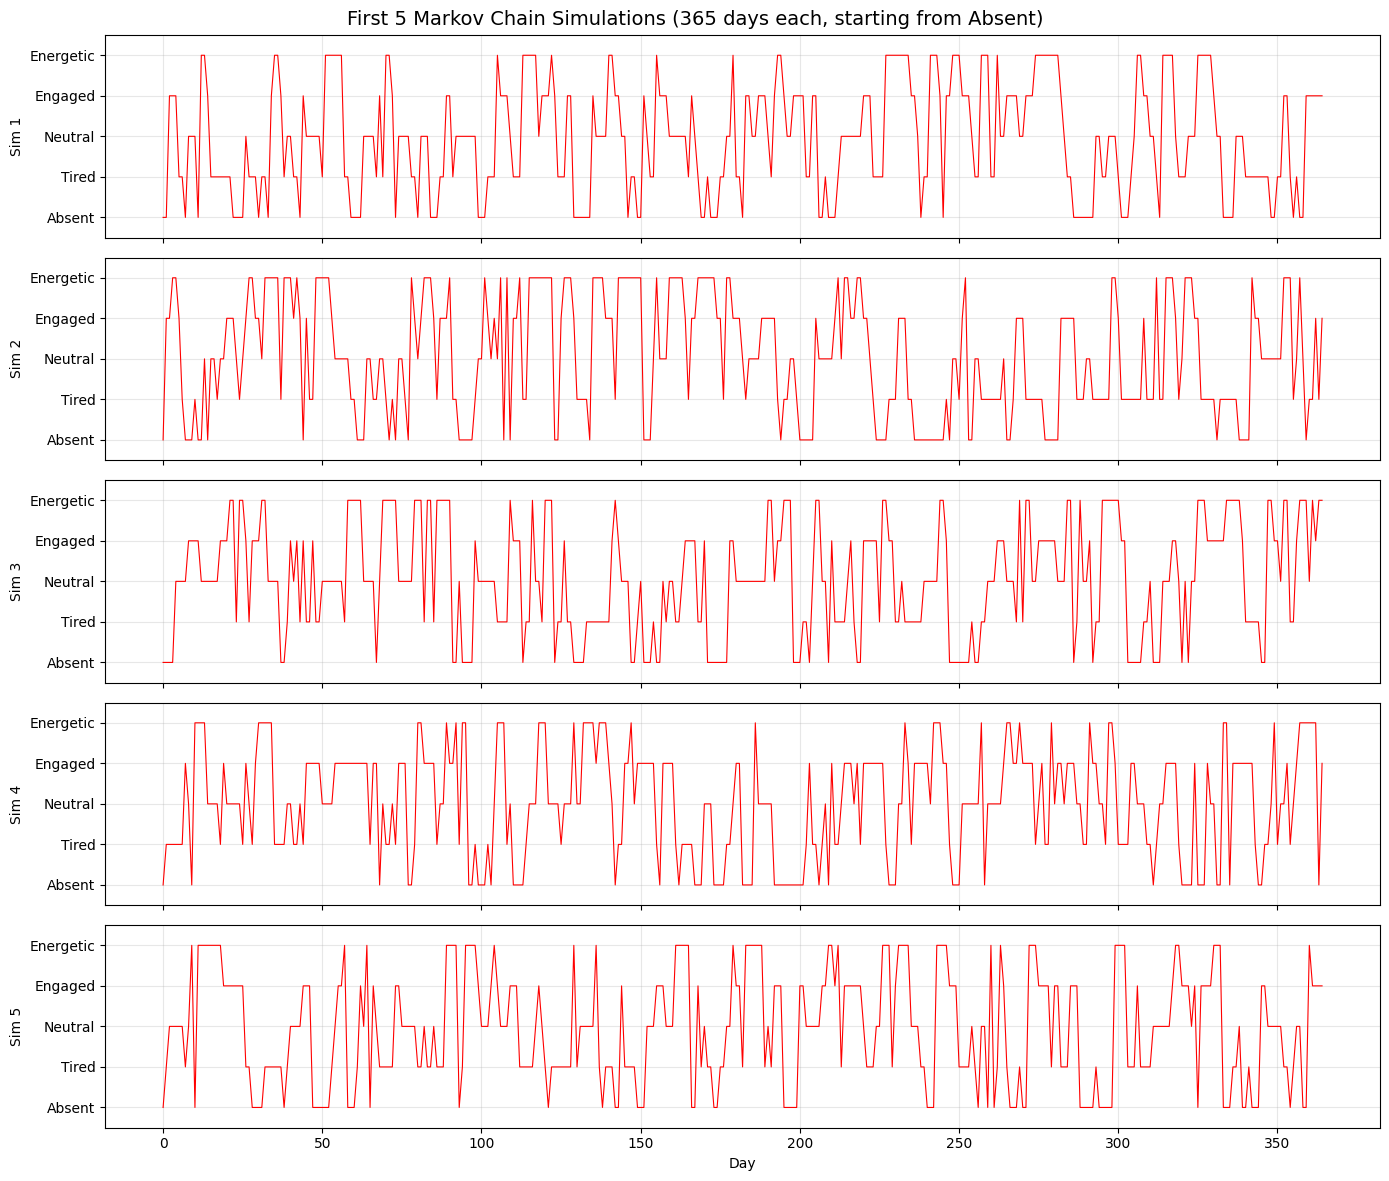


 All tasks completed!
   - Task 1: Single chain plotted
   - Task 2: 2000 simulations, empirical distribution calculated
   - Task 3: Stationary distribution found (2 methods) and compared


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

P = np.array([
    [0.60, 0.18, 0.11, 0.07, 0.04],
    [0.14, 0.51, 0.12, 0.13, 0.10],
    [0.07, 0.14, 0.59, 0.12, 0.08],
    [0.04, 0.17, 0.17, 0.51, 0.11],
    [0.07, 0.07, 0.05, 0.20, 0.61]
])

state_names = ["Absent", "Tired", "Neutral", "Engaged", "Energetic"]
state_colors = ['red', 'orange', 'gray', 'green', 'blue']

start_state = 0

def simulate_one_chain(length, P, start):
    states = np.zeros(length, dtype=int)
    states[0] = start
    for t in range(length - 1):
        current = states[t]
        states[t+1] = np.random.choice(len(P), p=P[current])
    return states


print("TASK 1: Single Chain Simulation (365 days)")


np.random.seed(42)
one_chain = simulate_one_chain(365, P, start_state)

plt.figure(figsize=(14, 5))
plt.plot(one_chain, linewidth=1, color='purple')
plt.yticks(range(5), state_names)
plt.xlabel("Day")
plt.ylabel("Mood State")
plt.title("Markov Chain Simulation - 365 Days (Starting from Absent)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

unique, counts = np.unique(one_chain, return_counts=True)
fractions_one = counts / 365

print("\nEmpirical fractions (1 chain, 365 days):")
for i, state in enumerate(state_names):
    print(f"  {state:10s}: {fractions_one[i]:.4f}")

print("\n")
print("TASK 2: 2000 Simulations, each 365 days")


num_simulations = 2000
chain_length = 365

all_states = []

np.random.seed(123)

for sim in range(num_simulations):
    chain = simulate_one_chain(chain_length, P, start_state)
    all_states.extend(chain)# Collect all 2000×365 = 730,000 numbers


all_states = np.array(all_states)
total_steps = num_simulations * chain_length

empirical_counts = np.zeros(len(P))

for s in all_states:
    empirical_counts[s] += 1

empirical_dist = empirical_counts / total_steps

print("\nEmpirical distribution across all 2000 simulations:")
for i, state in enumerate(state_names):
    print(f"  {state:10s}: {empirical_dist[i]:.6f}")

plt.figure(figsize=(10, 6))
bars = plt.bar(state_names, empirical_dist, color=state_colors, edgecolor='black')
plt.ylabel("Empirical Fraction")
plt.title(f"Empirical Distribution of Mood States ({num_simulations} simulations, {chain_length} days each)")
plt.ylim(0, 0.35)

for bar, val in zip(bars, empirical_dist):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n")
print("TASK 3: Stationary Distribution")


eigenvals, eigenvecs = eig(P.T)

idx = np.argmin(np.abs(eigenvals - 1.0))
pi_eigen = np.real(eigenvecs[:, idx])
pi_eigen = pi_eigen / np.sum(pi_eigen)

print("\nMethod 1 (Eigenvalue):")
for i, state in enumerate(state_names):
    print(f"  {state:10s}: {pi_eigen[i]:.8f}")

A = P.T - np.eye(len(P))
A_eq = np.vstack([A, np.ones(len(P))])
b_eq = np.zeros(len(P) + 1)
b_eq[-1] = 1.0

from numpy.linalg import lstsq

pi_linear, _, _, _ = lstsq(A_eq, b_eq, rcond=None)

print("\nMethod 2 (Linear system):")
for i, state in enumerate(state_names):
    print(f"  {state:10s}: {pi_linear[i]:.8f}")

print(f"\nMax difference between methods: {np.max(np.abs(pi_eigen - pi_linear)):.2e}")

print("\n")
print("COMPARISON: Stationary vs Empirical Distribution")


print(f"\n{'State':12s} {'Stationary':12s} {'Empirical':12s} {'Difference':12s}")
print("-" * 50)

for i, state in enumerate(state_names):
    diff = pi_eigen[i] - empirical_dist[i]
    print(f"{state:12s} {pi_eigen[i]:12.6f} {empirical_dist[i]:12.6f} {diff:12.6f}")

x = np.arange(len(state_names))
width = 0.35

plt.figure(figsize=(12, 7))
plt.bar(x - width/2, pi_eigen, width, label='Stationary (π)', color='skyblue', edgecolor='black')
plt.bar(x + width/2, empirical_dist, width, label='Empirical (2000 sims)', color='salmon', edgecolor='black')

plt.xticks(x, state_names)
plt.ylabel("Probability")
plt.title("Stationary Distribution vs Empirical Distribution")
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (stat, emp) in enumerate(zip(pi_eigen, empirical_dist)):
    plt.text(i - width/2, stat + 0.005, f'{stat:.4f}', ha='center', fontsize=9)
    plt.text(i + width/2, emp + 0.005, f'{emp:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n")
print("EXTRA: First 5 Simulations (each 365 days)")


np.random.seed(42)

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

for sim in range(5):
    chain = simulate_one_chain(365, P, start_state)
    axes[sim].plot(chain, linewidth=0.8, color=state_colors[chain[0] if len(chain) > 0 else 0])
    axes[sim].set_yticks(range(5))
    axes[sim].set_yticklabels(state_names)
    axes[sim].set_ylabel(f"Sim {sim+1}")
    axes[sim].grid(alpha=0.3)
    axes[sim].set_ylim(-0.5, 4.5)

axes[-1].set_xlabel("Day")

fig.suptitle("First 5 Markov Chain Simulations (365 days each, starting from Absent)", fontsize=14)

plt.tight_layout()
plt.show()

print("\n All tasks completed!")
print("   - Task 1: Single chain plotted")
print("   - Task 2: 2000 simulations, empirical distribution calculated")
print("   - Task 3: Stationary distribution found (2 methods) and compared")